### Plots-Only Notebook Pneumonia

The purpose of this notebook is to use recreate figures/plots to consider for illustrative purposes in the final report without retraining ResNet50.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_fscore_support,
    precision_recall_curve,
    average_precision_score,
)

oof_df  = pd.read_csv("resnet50_pneumonia_cv_oof_predictions.csv")
test_df = pd.read_csv("resnet50_pneumonia_cv_test_predictions.csv")

y_true_oof  = oof_df["y_true"].values
y_prob_oof  = oof_df["y_prob"].values
y_true_test = test_df["y_true"].values
y_prob_test = test_df["y_prob"].values

In [4]:
thresholds = np.linspace(0.0, 1.0, 1001)

f1_scores = []
f2_scores = []

for t in thresholds:
    y_pred = (y_prob_oof >= t).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_oof, y_pred, average="binary", zero_division=0
    )
    beta = 2.0
    if prec + rec == 0:
        f2 = 0.0
    else:
        f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec)
    f1_scores.append(f1)
    f2_scores.append(f2)

f1_scores = np.array(f1_scores)
f2_scores = np.array(f2_scores)

t_f1 = thresholds[np.argmax(f1_scores)]
t_f2 = thresholds[np.argmax(f2_scores)]

print("F1-optimal threshold:", t_f1)
print("F2-optimal threshold:", t_f2)

F1-optimal threshold: 0.456
F2-optimal threshold: 0.17


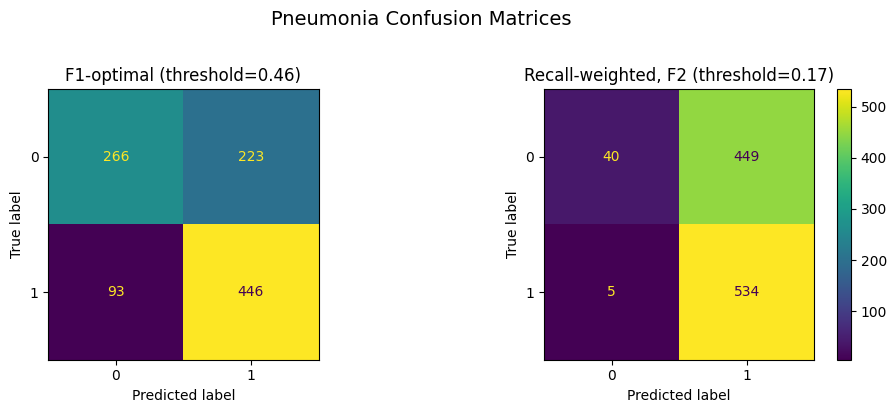

In [10]:
# Binarize predictions at each threshold
y_pred_f1 = (y_prob_test >= t_f1).astype(int)
y_pred_f2 = (y_prob_test >= t_f2).astype(int)

cm_f1 = confusion_matrix(y_true_test, y_pred_f1)
cm_f2 = confusion_matrix(y_true_test, y_pred_f2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Shared Title
fig.suptitle("Pneumonia Confusion Matrices", fontsize=14, y=1.02)

# F1-optimal
disp_f1 = ConfusionMatrixDisplay(cm_f1, display_labels=[0, 1])
disp_f1.plot(ax=axes[0], cmap="viridis", colorbar=False)
axes[0].set_title(f"F1-optimal (threshold={t_f1:.2f})")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

# Recall-weighted (F2)
disp_f2 = ConfusionMatrixDisplay(cm_f2, display_labels=[0, 1])
disp_f2.plot(ax=axes[1], cmap="viridis", colorbar=True)
axes[1].set_title(f"Recall-weighted, F2 (threshold={t_f2:.2f})")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

plt.tight_layout()
plt.show()


Test @ F1-opt (t=0.46):  precision=0.667, recall=0.827
Test @ F2-opt (t=0.17):  precision=0.543, recall=0.991


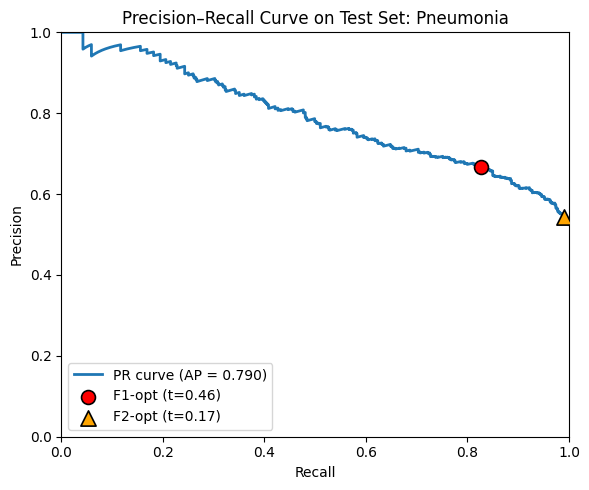

In [12]:
# At those thresholds on the TEST set

def prec_rec_at_threshold(y_true, y_prob, t):
    y_pred = (y_prob >= t).astype(int)
    prec, rec, _, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    return prec, rec

prec_f1, rec_f1 = prec_rec_at_threshold(y_true_test, y_prob_test, t_f1)
prec_f2, rec_f2 = prec_rec_at_threshold(y_true_test, y_prob_test, t_f2)

print(f"\nTest @ F1-opt (t={t_f1:.2f}):  precision={prec_f1:.3f}, recall={rec_f1:.3f}")
print(f"Test @ F2-opt (t={t_f2:.2f}):  precision={prec_f2:.3f}, recall={rec_f2:.3f}")

# --- 3. Precision–Recall curve on TEST set ---

prec_curve, rec_curve, _ = precision_recall_curve(y_true_test, y_prob_test)
ap = average_precision_score(y_true_test, y_prob_test)

plt.figure(figsize=(6, 5))
# Draw the PR curve first, with lower zorder
plt.plot(
    rec_curve,
    prec_curve,
    label=f"PR curve (AP = {ap:.3f})",
    linewidth=2,
    zorder=1
)

# Draw F1 point on top
plt.scatter(
    rec_f1,
    prec_f1,
    s=100,
    marker="o",
    edgecolor="black",
    color='red',
    linewidth=1.2,
    label=f"F1-opt (t={t_f1:.2f})",
    zorder=3
)

# Draw F2 point on top
plt.scatter(
    rec_f2,
    prec_f2,
    s=120,
    marker="^",
    edgecolor="black",
    color='orange',
    linewidth=1.2,
    label=f"F2-opt (t={t_f2:.2f})",
    zorder=3
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve on Test Set: Pneumonia")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()